# Importing modules

In [2]:
import numpy as np 
import skimage
import skimage.io
import matplotlib.pyplot as plt

skimage stands for sckit-image , library used for image processing

In [3]:
image  = skimage.io.imread('https://cildata.crbs.ucsd.edu/media/images/13901/13901.tif')

In [6]:
image = skimage.io.imread('sample_image.jpg')

# Image as arrays

In [8]:
image, type(image)

(array([[[ 72,  96, 130],
         [ 67,  93, 128],
         [ 89, 114, 154],
         ...,
         [ 50,  64,  65],
         [ 56,  70,  81],
         [ 11,  26,  45]],
 
        [[ 55,  80, 111],
         [ 40,  65,  96],
         [ 30,  54,  90],
         ...,
         [109, 122, 141],
         [ 48,  62,  89],
         [ 45,  59,  94]],
 
        [[ 42,  66,  92],
         [ 21,  45,  73],
         [  0,  12,  43],
         ...,
         [ 78,  92, 131],
         [ 23,  37,  84],
         [108, 123, 178]],
 
        ...,
 
        [[ 24,  40,  14],
         [ 24,  40,  14],
         [ 23,  39,  13],
         ...,
         [ 15,  25,  14],
         [ 20,  30,  19],
         [ 22,  33,  19]],
 
        [[ 29,  45,  19],
         [ 29,  45,  19],
         [ 28,  44,  18],
         ...,
         [ 14,  24,  13],
         [ 20,  30,  19],
         [ 23,  34,  20]],
 
        [[ 33,  49,  23],
         [ 33,  49,  23],
         [ 31,  47,  21],
         ...,
         [ 12,  22,  11],
  

In [9]:
image.shape

(388, 517, 3)

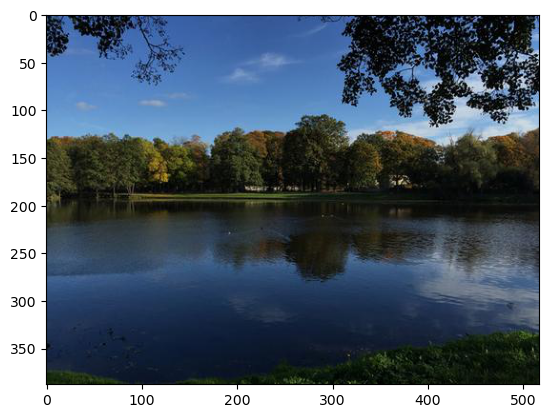

In [12]:
plt.imshow(image, cmap='gray')

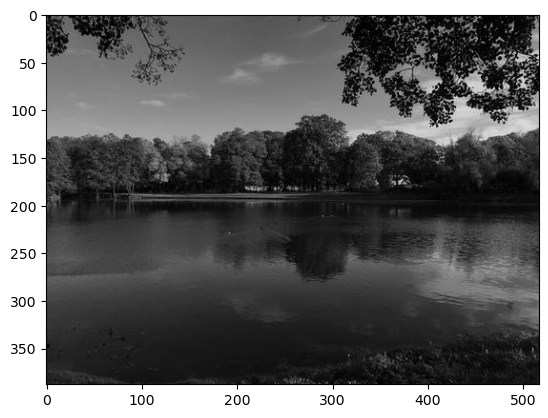

In [15]:
bnw_im = skimage.io.imread('sample_image.jpg',as_gray=True)
plt.imshow(bnw_im, cmap='gray')

In [17]:
bnw_im.shape

(388, 517)

In [20]:
cropped = image[200:300, 300:400].copy()

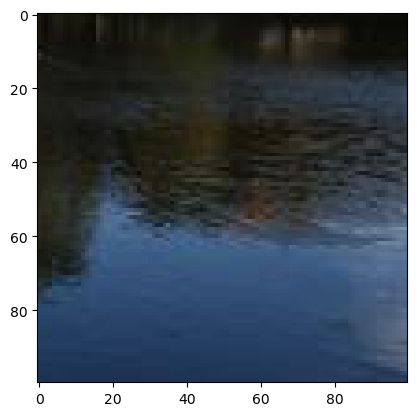

In [21]:
plt.imshow(cropped)

In [22]:
cropped.shape

(100, 100, 3)

In [41]:
noise_image = np.random.poisson(lam=3, size=cropped.shape)
corrupted = cropped + 10*noise_image

In [42]:
noise_image.shape

(100, 100, 3)

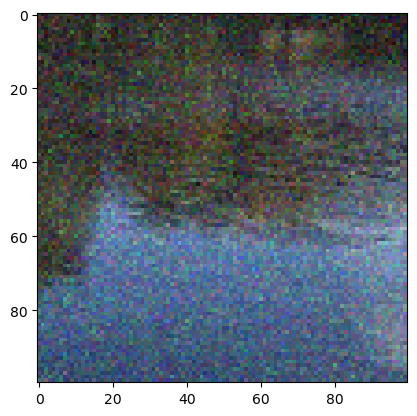

In [43]:
plt.imshow(corrupted, cmap='gray')

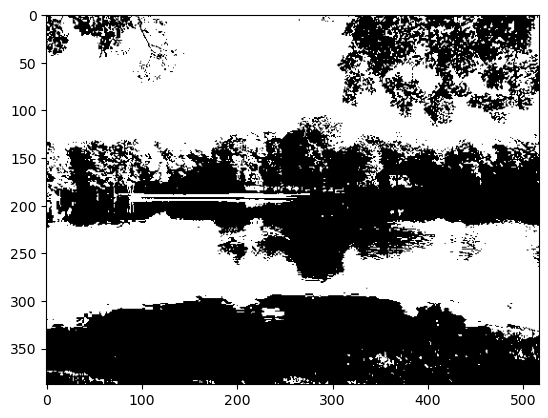

In [53]:
array_bool = bnw_im > 0.2
plt.imshow(array_bool, cmap='gray')

In [62]:
ax.shape

(3,)

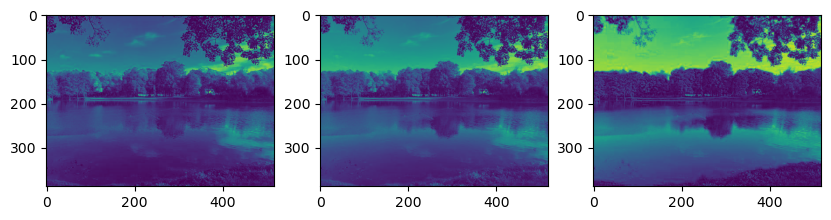

In [63]:
fig, ax = plt.subplots(1,3, figsize=(10,10))
ax[0].imshow(image[:,:,0])
ax[1].imshow(image[:,:,1])
ax[2].imshow(image[:,:,2])

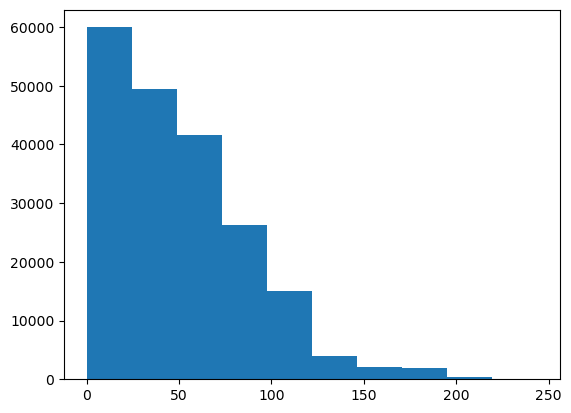

In [67]:
image_ch1 = image[:,:,0]
plt.hist(image_ch1.ravel());

In [68]:
image_ch1[0,0]

np.uint8(72)

each pixel value is an 8bit int so possible values are in range (0-255)

if we subtract a greater value from a pixel it will overflow and subtract from 255 the difference

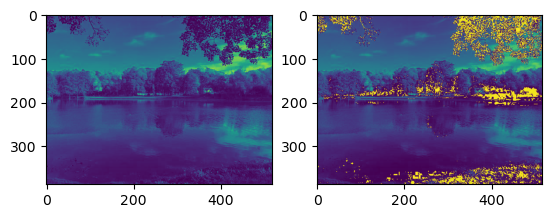

In [70]:
fig, ax = plt.subplots(1, 2)
ax[0].imshow(image_ch1) 
ax[1].imshow(image_ch1-10)

 to overcome this we can change our image into some other datatype like float

# Thresholding

In [93]:
image_sky = image[:,:,2]

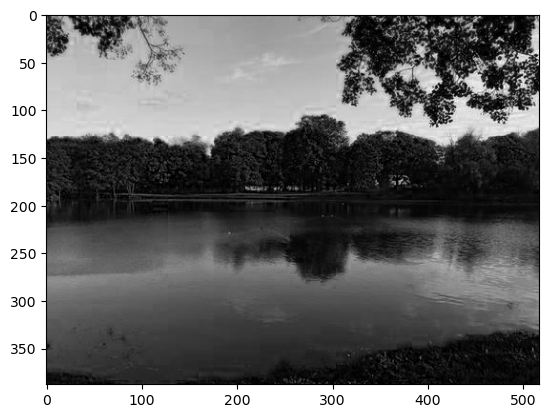

In [94]:
plt.imshow(image_sky, cmap='gray')

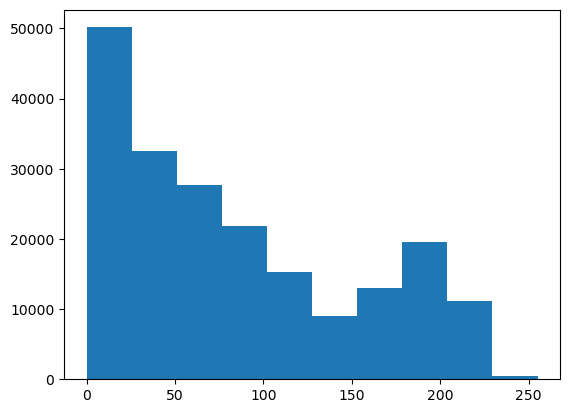

In [96]:
plt.hist(image_sky.ravel());

## Manual Thresholding

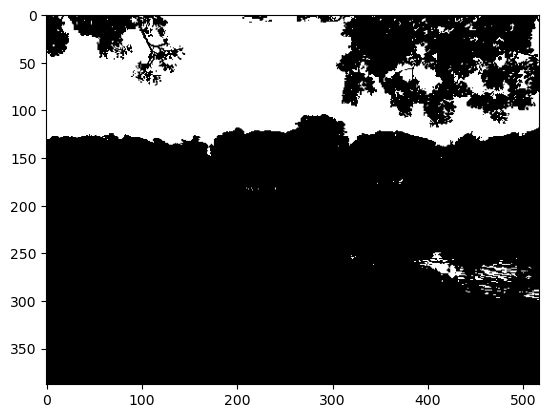

In [106]:
mask = image_sky > 150
plt.imshow(mask, cmap='gray')

## Automatic thresholding : otsu algorithm

In [107]:
help(skimage.filters.threshold_otsu)

Help on function threshold_otsu in module skimage.filters.thresholding:

threshold_otsu(image=None, nbins=256, *, hist=None)
    Return threshold value based on Otsu's method.

    Either image or hist must be provided. If hist is provided, the actual
    histogram of the image is ignored.

    Parameters
    ----------
    image : (M, N[, ...]) ndarray, optional
        Grayscale input image.
    nbins : int, optional
        Number of bins used to calculate histogram. This value is ignored for
        integer arrays.
    hist : array, or 2-tuple of arrays, optional
        Histogram from which to determine the threshold, and optionally a
        corresponding array of bin center intensities. If no hist provided,
        this function will compute it from the image.


    Returns
    -------
    threshold : float
        Upper threshold value. All pixels with an intensity higher than
        this value are assumed to be foreground.

    References
    ----------
    .. [1] Wikipedia, 

In [108]:
sky_otsu_threshold = skimage.filters.threshold_otsu(image_sky)
print(sky_otsu_threshold)

106


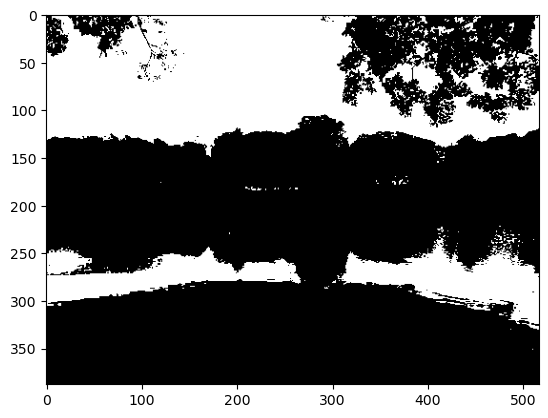

In [109]:
mask_img = image_sky > sky_otsu_threshold
plt.imshow(mask_img, cmap = 'gray')

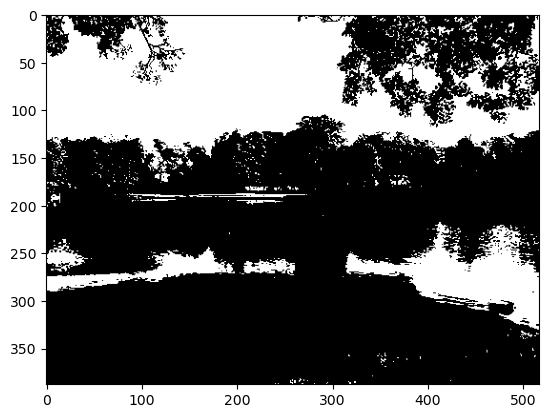

In [112]:
tree_img = image[:,:,1]
tree_threshold = skimage.filters.threshold_otsu(tree_img)
tree_mask = tree_img > tree_threshold
plt.imshow(tree_mask , cmap='gray')

# Filters

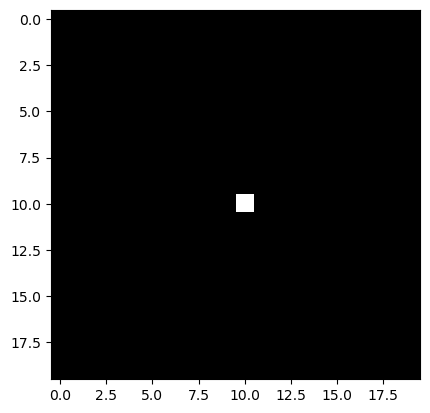

In [113]:
single_dot = np.zeros((20,20))
single_dot[10,10] = 1
plt.imshow(single_dot, cmap = 'gray');

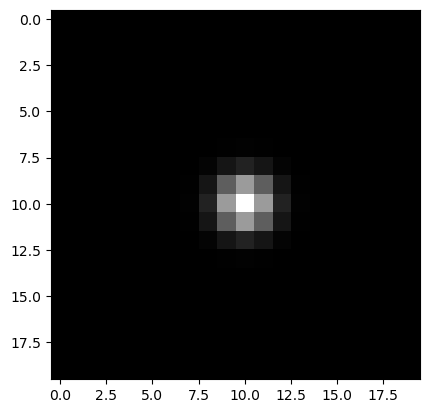

In [115]:
filtered = skimage.filters.gaussian(single_dot)
plt.imshow(filtered, cmap = 'gray');

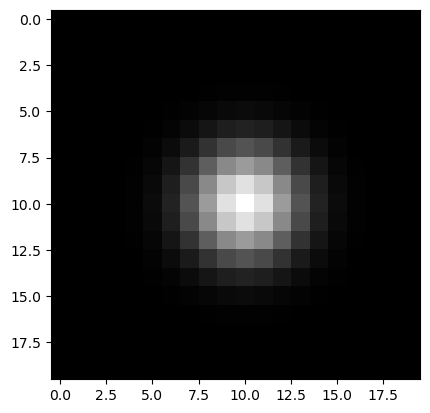

In [116]:
filtered = skimage.filters.gaussian(single_dot,sigma=2)
plt.imshow(filtered, cmap = 'gray');

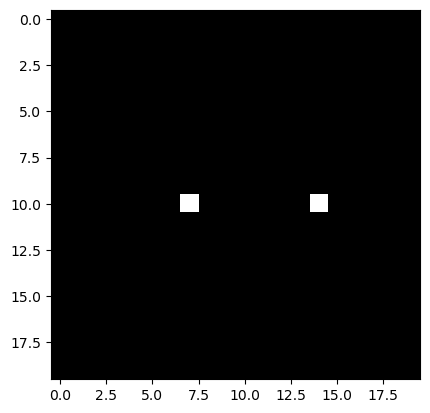

In [117]:
double_dot = np.zeros((20,20))
double_dot[10,7] = 1
double_dot[10,14] = 1
plt.imshow(double_dot, cmap = 'gray');

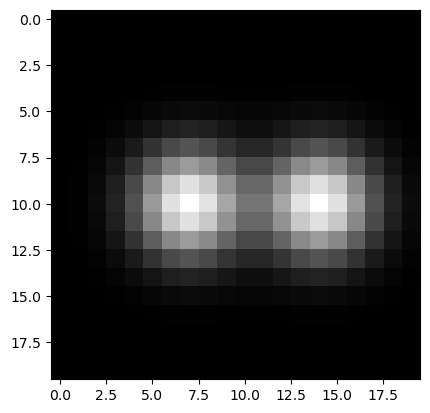

In [118]:
filtered = skimage.filters.gaussian(double_dot,sigma=2)
plt.imshow(filtered, cmap = 'gray');

## Removing noise

In [119]:
noisy = filtered + 0.02*np.random.rand(20,20)

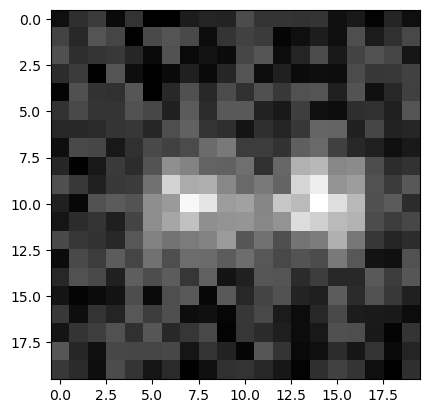

In [120]:
plt.imshow(noisy, cmap = 'gray');

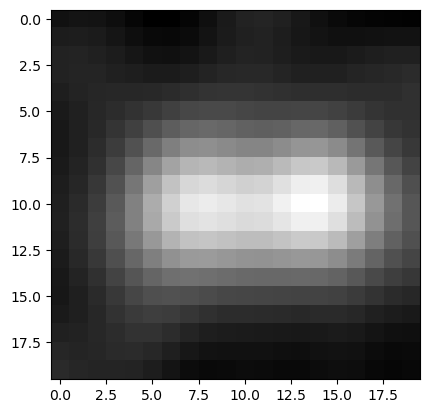

In [127]:
noise_filtered = skimage.filters.gaussian(noisy,sigma=2)
plt.imshow(noise_filtered, cmap = 'gray');

## Non-Linear filters

In [128]:
#image_stack = skimage.io.imread('images/46658_784_B12_1.tif')
image_stack = skimage.io.imread('https://github.com/guiwitz/PyImageCourse_beginner/raw/master/images/46658_784_B12_1.tif')
image_nuclei = image_stack[1250:1750,300:800,2]

In [129]:
image_noisy = skimage.util.random_noise(image_nuclei, mode='s&p')

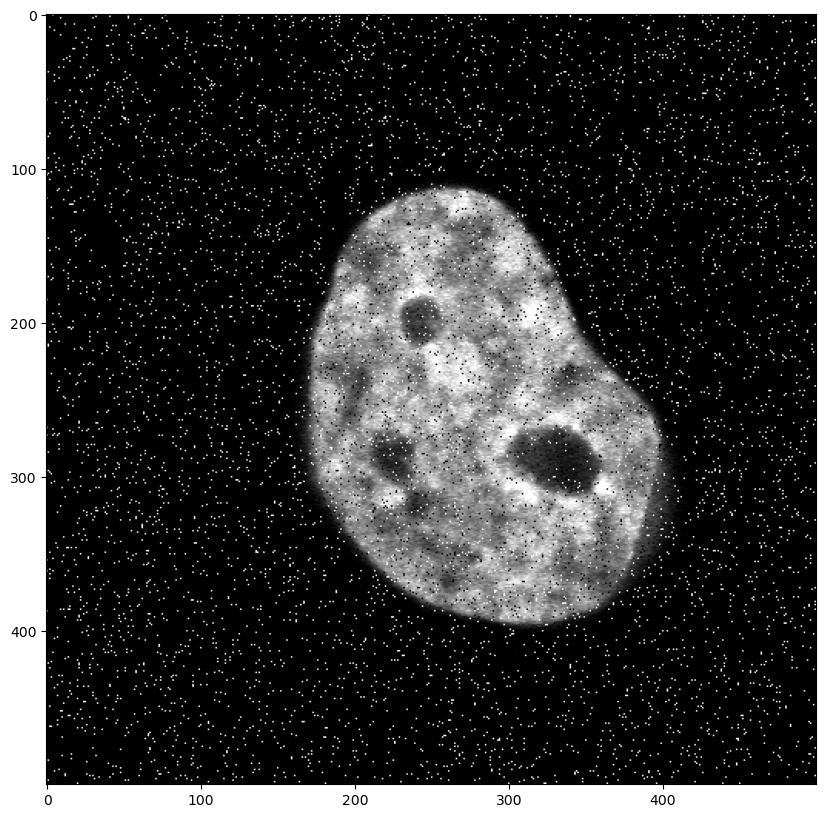

In [130]:
plt.subplots(figsize=(10,10))
plt.imshow(image_noisy, cmap = 'gray');

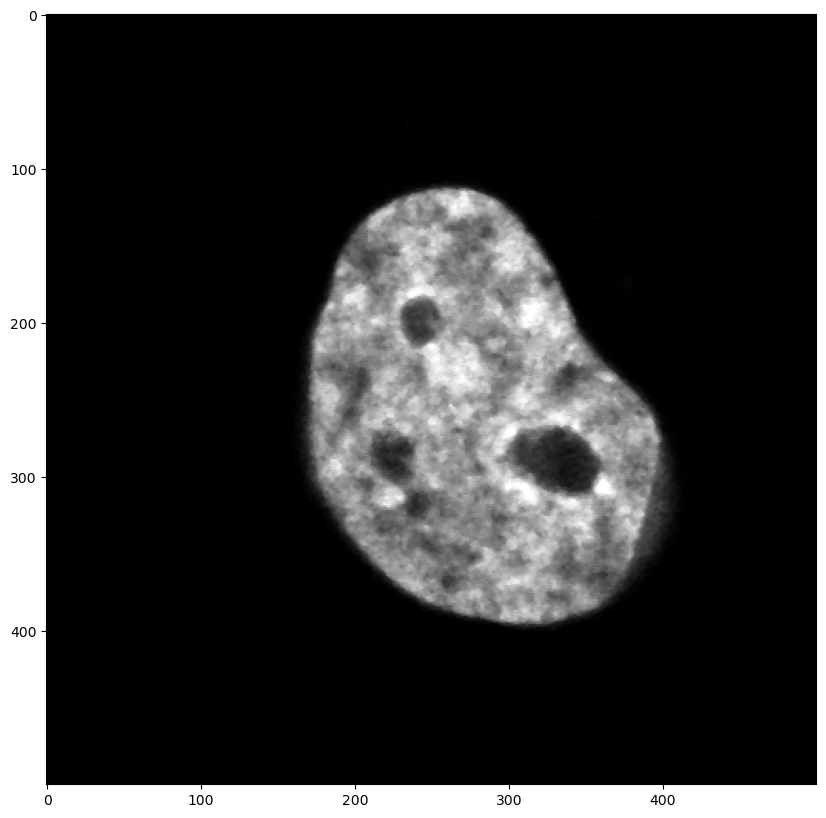

In [131]:
filtered_median = skimage.filters.median(image_noisy)

plt.subplots(figsize=(10,10))
plt.imshow(filtered_median, cmap = 'gray');

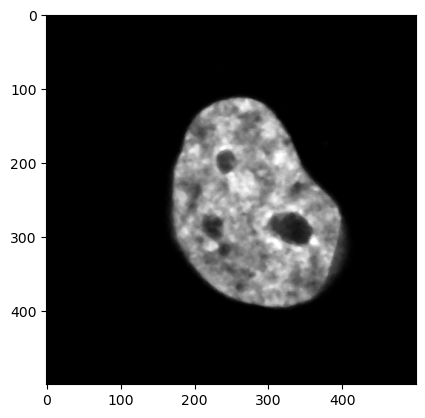

In [132]:
footprint = np.ones((5,5))
filtered_median = skimage.filters.median(image_noisy, footprint=footprint)
plt.imshow(filtered_median, cmap = 'gray');

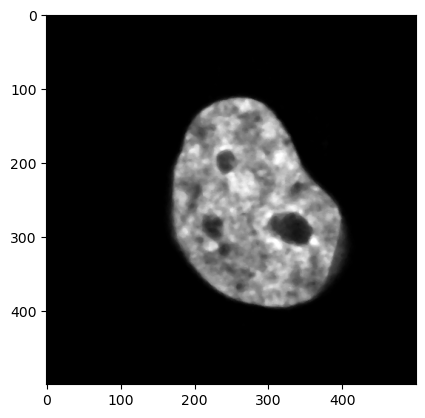

In [133]:
footprint = skimage.morphology.disk(3)
filtered_median = skimage.filters.median(image_noisy, footprint=footprint)
plt.imshow(filtered_median, cmap = 'gray');

## Morphological filters

turn pixels on or off based on their surroundings

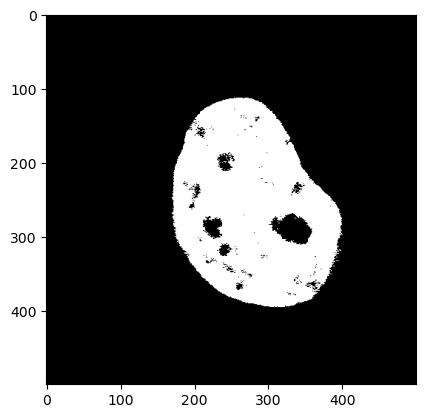

In [134]:
mask = image_nuclei > skimage.filters.threshold_otsu(image_nuclei)

plt.imshow(mask, cmap = 'gray');

In [135]:
influence_region = np.ones((5,5))
eroded = skimage.morphology.binary_erosion(mask, footprint=influence_region)

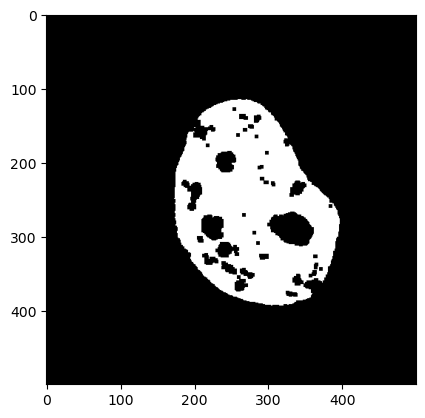

In [136]:
plt.imshow(eroded, cmap = 'gray');

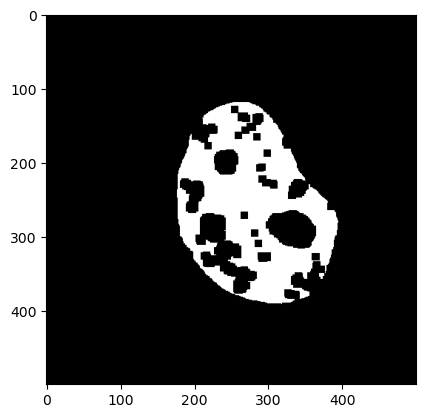

In [137]:
influence_region = np.ones((10,10))

eroded = skimage.morphology.binary_erosion(mask, footprint=influence_region)

plt.imshow(eroded, cmap = 'gray');

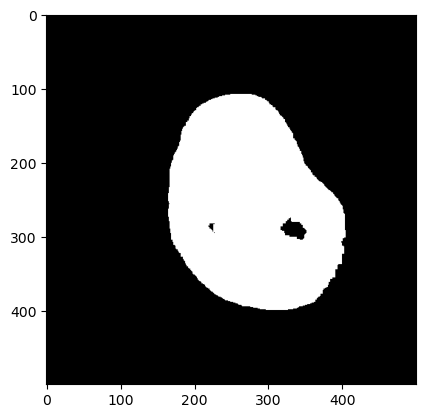

In [138]:
influence_region = np.ones((10,10))

dilated = skimage.morphology.binary_dilation(mask, footprint=influence_region)

plt.imshow(dilated, cmap = 'gray');

## removing noise using dilation and erroding 

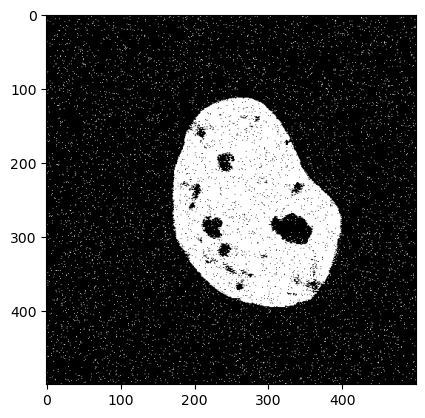

In [139]:
mask = image_noisy > skimage.filters.threshold_otsu(image_noisy)

plt.imshow(mask, cmap = 'gray');

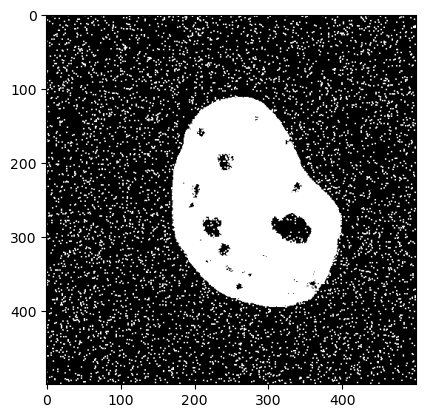

In [140]:
influence_region = np.ones((2,2))

step1 = skimage.morphology.binary_dilation(mask, footprint=influence_region)

plt.imshow(step1, cmap = 'gray');

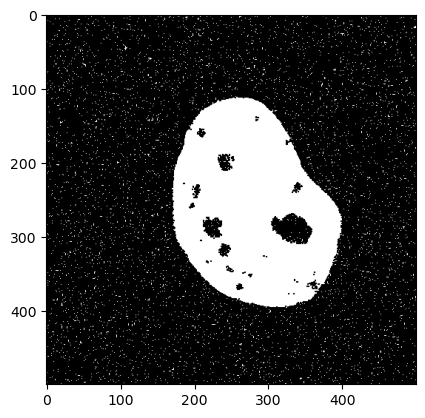

In [142]:
influence_region = np.ones((2,2))

step2 = skimage.morphology.binary_erosion(step1, footprint=influence_region)

plt.imshow(step2, cmap = 'gray');

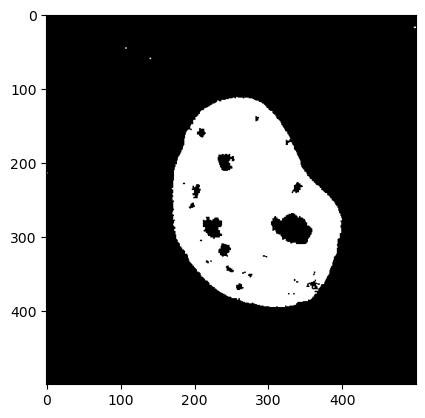

In [143]:
influence_region = np.ones((2,2))

step3 = skimage.morphology.binary_erosion(step2, footprint=influence_region)
step4 = skimage.morphology.binary_dilation(step3, footprint=influence_region)

plt.imshow(step4, cmap = 'gray');

### binary closing : does a dialtion and then erosion

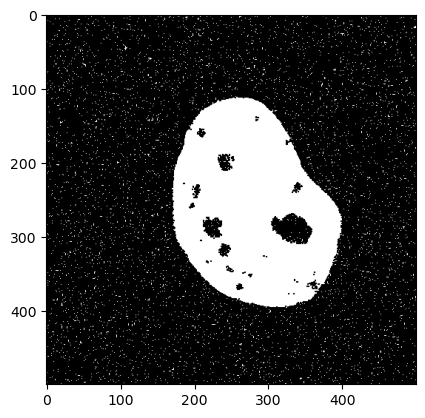

In [144]:
plt.imshow(skimage.morphology.binary_closing(mask, footprint=influence_region), cmap='gray');

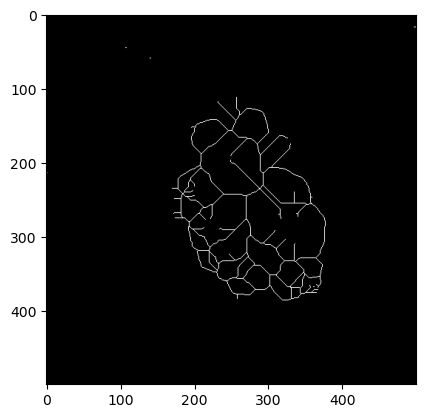

In [145]:
skeleton = skimage.morphology.skeletonize(step4)

plt.imshow(skeleton, cmap = 'gray');

# Regional Properties

In [147]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skimage
import skimage.io
import skimage.morphology
import scipy.ndimage as ndi

In [148]:
#image_stack = skimage.io.imread('images/46658_784_B12_1.tif')
image_stack = skimage.io.imread('https://github.com/guiwitz/PyImageCourse_beginner/raw/master/images/46658_784_B12_1.tif')

image_nuclei = image_stack[:,:,2]#blue channel in RGB
image_signal = image_stack[:,:,1]#green channel in RGB

# filter image
image_nuclei = skimage.filters.median(image_nuclei, skimage.morphology.disk(5))

# create mask and clean-up
mask_nuclei = image_nuclei > skimage.filters.threshold_otsu(image_nuclei)
mask_nuclei = skimage.morphology.binary_closing(mask_nuclei, footprint=skimage.morphology.disk(5))
mask_nuclei = ndi.binary_fill_holes(mask_nuclei, skimage.morphology.disk(5))

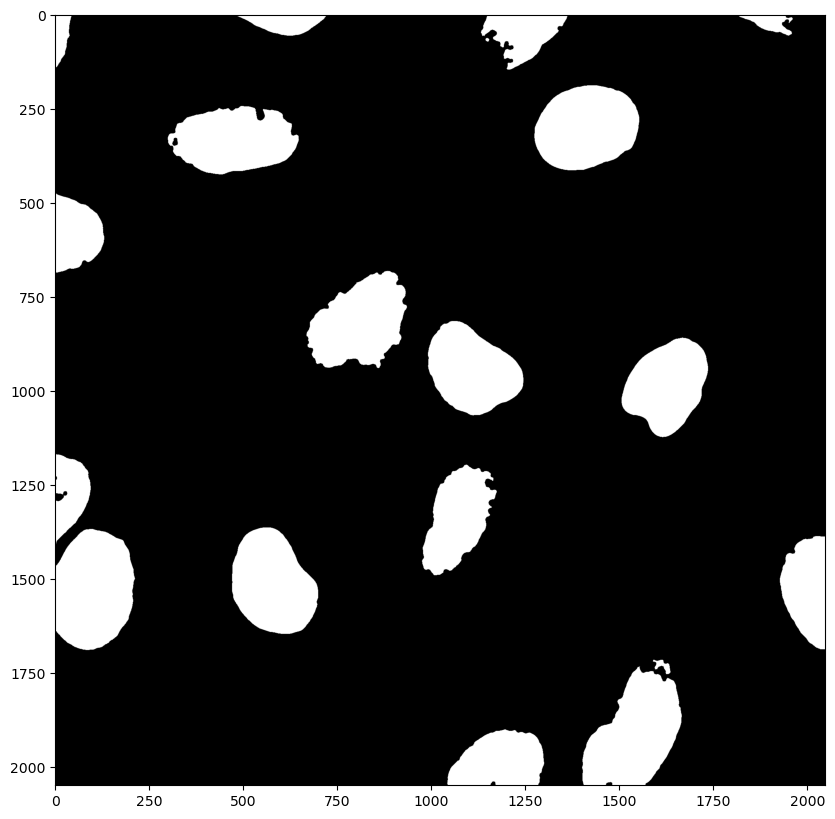

In [153]:
plt.subplots(figsize=(10,10))
plt.imshow(mask_nuclei, cmap = 'gray');

## Labeling

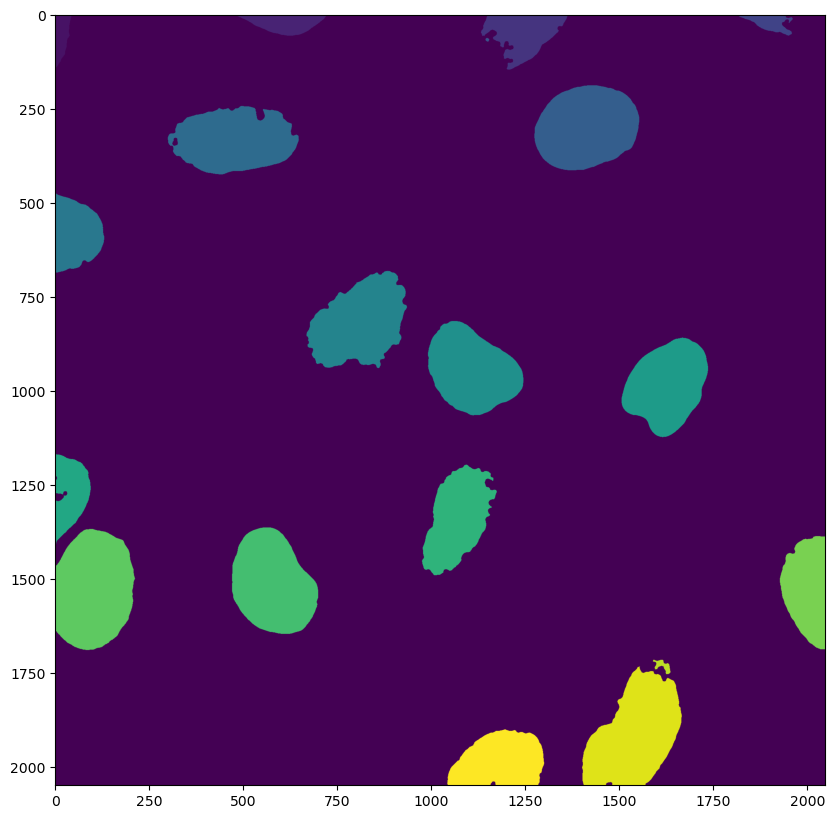

In [154]:
my_labels = skimage.morphology.label(mask_nuclei)
plt.subplots(figsize=(10,10))
plt.imshow(my_labels);

In [155]:
my_regions = skimage.measure.regionprops_table(my_labels, properties=('label','area'))

In [156]:
my_regions

{'label': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20]),
 'area': array([4.2210e+03, 8.3860e+03, 1.8258e+04, 4.0430e+03, 7.3000e+01,
        4.9056e+04, 4.5671e+04, 2.0537e+04, 4.6853e+04, 4.3277e+04,
        4.0768e+04, 1.5090e+04, 3.5404e+04, 4.7642e+04, 5.4978e+04,
        2.6774e+04, 4.0000e+00, 8.1200e+02, 5.4298e+04, 2.9638e+04])}

In [157]:
my_regions = skimage.measure.regionprops_table(
    my_labels,intensity_image=image_signal, properties=('label','area','mean_intensity'))

In [158]:
my_regions

{'label': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20]),
 'area': array([4.2210e+03, 8.3860e+03, 1.8258e+04, 4.0430e+03, 7.3000e+01,
        4.9056e+04, 4.5671e+04, 2.0537e+04, 4.6853e+04, 4.3277e+04,
        4.0768e+04, 1.5090e+04, 3.5404e+04, 4.7642e+04, 5.4978e+04,
        2.6774e+04, 4.0000e+00, 8.1200e+02, 5.4298e+04, 2.9638e+04]),
 'mean_intensity': array([ 79.26510306,  65.99773432,  70.26109103,  63.02671284,
         47.43835616,  53.71450995,  53.8070986 ,  70.45391245,
         66.13772864,  41.4125517 ,  58.67503925,  44.19814447,
         74.77155124,  41.70190168,  35.9041071 ,  53.07787406,
        112.        , 102.9864532 ,  56.11020664,  66.28379108])}

In [159]:
my_regions_df = pd.DataFrame(my_regions)
my_regions_df

,label,area,mean_intensity
0,1,4221.0,79.265103
1,2,8386.0,65.997734
2,3,18258.0,70.261091
3,4,4043.0,63.026713
4,5,73.0,47.438356
5,6,49056.0,53.714510
6,7,45671.0,53.807099
7,8,20537.0,70.453912
8,9,46853.0,66.137729
9,10,43277.0,41.412552


In [160]:
my_regions_df[my_regions_df['area'] > 100]

,label,area,mean_intensity
0,1,4221.0,79.265103
1,2,8386.0,65.997734
2,3,18258.0,70.261091
3,4,4043.0,63.026713
5,6,49056.0,53.714510
6,7,45671.0,53.807099
7,8,20537.0,70.453912
8,9,46853.0,66.137729
9,10,43277.0,41.412552
10,11,40768.0,58.675039


# Pipeline

In [161]:
def my_pipeline(image_path):
    """
    This function extracts information about nuclei found in the third channel of an image
    loaded at the given path
    
    Parameters
    ----------
    image_path: str
        path to image
        
    Returns
    -------
    my_table: pandas dataframe
        dataframe with label, area, mean_intensity and extent information for each nucleus
    
    """
    
    image_stack = skimage.io.imread(image_path)
    
    image_nuclei = image_stack[:,:,2]#blue channel in RGB
    image_signal = image_stack[:,:,1]#green channel in RGB

    # filter image
    image_nuclei = skimage.filters.median(image_nuclei, skimage.morphology.disk(5))

    # create mask and clean-up
    mask_nuclei = image_nuclei > skimage.filters.threshold_otsu(image_nuclei)
    mask_nuclei = skimage.morphology.binary_closing(mask_nuclei, footprint=skimage.morphology.disk(5))
    mask_nuclei = ndi.binary_fill_holes(mask_nuclei, skimage.morphology.disk(5))
    
    # label image
    my_labels = skimage.morphology.label(mask_nuclei)

    # measure
    my_regions = skimage.measure.regionprops_table(my_labels, image_signal, properties=('label','area', 'mean_intensity'))
    
    plt.subplots(figsize=(10,10))
    plt.imshow(mask_nuclei)
    plt.show()
    
    my_table = pd.DataFrame(my_regions)
    
    return my_table
                
                

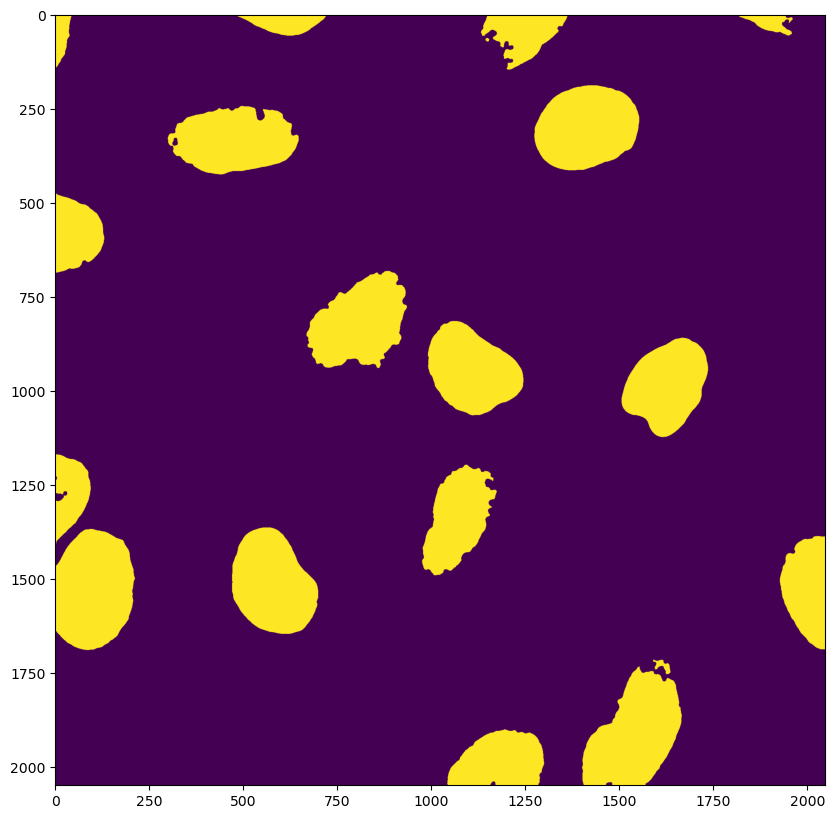

In [162]:
table = my_pipeline('https://github.com/guiwitz/PyImageCourse_beginner/raw/master/images/46658_784_B12_1.tif')

In [163]:
table

,label,area,mean_intensity
0,1,4221.0,79.265103
1,2,8386.0,65.997734
2,3,18258.0,70.261091
3,4,4043.0,63.026713
4,5,73.0,47.438356
5,6,49056.0,53.714510
6,7,45671.0,53.807099
7,8,20537.0,70.453912
8,9,46853.0,66.137729
9,10,43277.0,41.412552


# OpenCV

In [1]:
import cv2

In [165]:
img = cv2.imread('sample_image.jpg')
cv2.imshow('Image', img)

QObject::moveToThread: Current thread (0x153e6400) is not the object's thread (0x153d3640).
Cannot move to target thread (0x153e6400)

QObject::moveToThread: Current thread (0x153e6400) is not the object's thread (0x153d3640).
Cannot move to target thread (0x153e6400)

QObject::moveToThread: Current thread (0x153e6400) is not the object's thread (0x153d3640).
Cannot move to target thread (0x153e6400)

QObject::moveToThread: Current thread (0x153e6400) is not the object's thread (0x153d3640).
Cannot move to target thread (0x153e6400)

QObject::moveToThread: Current thread (0x153e6400) is not the object's thread (0x153d3640).
Cannot move to target thread (0x153e6400)

QObject::moveToThread: Current thread (0x153e6400) is not the object's thread (0x153d3640).
Cannot move to target thread (0x153e6400)

QObject::moveToThread: Current thread (0x153e6400) is not the object's thread (0x153d3640).
Cannot move to target thread (0x153e6400)

QObject::moveToThread: Current thread (0x153e6400) is n